In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mahbubaeka/dhaka-hourly-pm2-5-airnow-openaq-8415/pm25_sensor_24434.csv


In [4]:
file_path = "/kaggle/input/datasets/mahbubaeka/dhaka-hourly-pm2-5-airnow-openaq-8415/pm25_sensor_24434.csv"
df = pd.read_csv(file_path)
print(df.shape)
df.head()


NameError: name 'pd' is not defined

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66379 entries, 0 to 66378
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   value       61229 non-null  float64
 1   from_utc    66379 non-null  object 
 2   to_utc      66379 non-null  object 
 3   from_local  66379 non-null  object 
 4   to_local    66379 non-null  object 
dtypes: float64(1), object(4)
memory usage: 2.5+ MB


In [4]:
print(df["value"].isna().sum())
print(len(df) - df["value"].count())

5150
5150


In [5]:
df["start_utc"] = pd.to_datetime(df["from_utc"], utc=True)
print(df["start_utc"].dtype)
print(df["start_utc"].min())
print(df["start_utc"].max())

datetime64[ns, UTC]
2016-11-09 17:00:00+00:00
2025-03-24 12:00:00+00:00


In [6]:
first = df["start_utc"].min()
last = df["start_utc"].max()
expected = int((last - first) / pd.Timedelta(hours=1)) + 1
print(expected)
print(len(df))
print(expected - len(df))


73364
66379
6985


In [7]:
print(df["start_utc"].duplicated().sum())
print(df["start_utc"].is_unique)

0
True


In [9]:
top = df.nlargest(10, "value")[["value", "from_local"]]
top

,value,from_local
11812,985.0,2018-07-25T14:00:00+06:00
11813,985.0,2018-07-25T15:00:00+06:00
11832,985.0,2018-07-26T11:00:00+06:00
11860,985.0,2018-07-27T17:00:00+06:00
11871,985.0,2018-07-28T04:00:00+06:00
11872,985.0,2018-07-28T06:00:00+06:00
11923,985.0,2018-07-30T11:00:00+06:00
11925,985.0,2018-07-30T13:00:00+06:00
11926,985.0,2018-07-30T14:00:00+06:00
11945,985.0,2018-07-31T11:00:00+06:00


In [10]:
top = df.nlargest(10, "value")[["value", "from_local"]]
top

,value,from_local
11812,985.0,2018-07-25T14:00:00+06:00
11813,985.0,2018-07-25T15:00:00+06:00
11832,985.0,2018-07-26T11:00:00+06:00
11860,985.0,2018-07-27T17:00:00+06:00
11871,985.0,2018-07-28T04:00:00+06:00
11872,985.0,2018-07-28T06:00:00+06:00
11923,985.0,2018-07-30T11:00:00+06:00
11925,985.0,2018-07-30T13:00:00+06:00
11926,985.0,2018-07-30T14:00:00+06:00
11945,985.0,2018-07-31T11:00:00+06:00


In [8]:
df["value"].describe()

count    61229.000000
mean        96.135743
std         84.505664
min          0.000000
25%         36.000000
50%         68.000000
75%        135.000000
max        985.000000
Name: value, dtype: float64

In [11]:
at_max = df[df["value"] == 985.0]
print(len(at_max))
print(at_max["start_utc"].min())
print(at_max["start_utc"].max())

43
2018-07-25 08:00:00+00:00
2022-10-10 06:00:00+00:00


In [12]:
at_max["start_utc"].dt.strftime("%Y-%m").value_counts().sort_index()

start_utc
2018-07    10
2018-08    18
2018-09     4
2019-01     1
2019-02     3
2019-05     1
2022-08     3
2022-09     1
2022-10     2
Name: count, dtype: int64

In [13]:
df["month"] = df["start_utc"].dt.strftime("%Y-%m")
valid = df.dropna(subset=["value"])
valid_per_month = valid["month"].value_counts().sort_index()
valid_per_month.loc[["2018-07", "2018-08", "2018-09"]]

month
2018-07    611
2018-08    335
2018-09      4
Name: count, dtype: int64

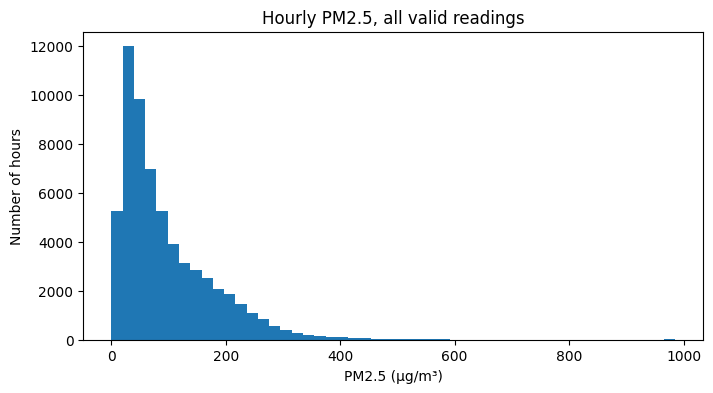

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df["value"].dropna(), bins=50)
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Number of hours")
plt.title("Hourly PM2.5, all valid readings")
plt.show()

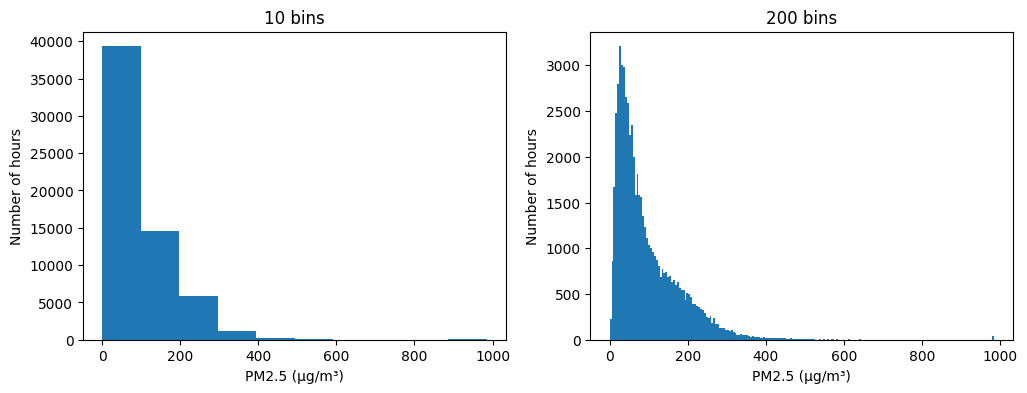

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["value"].dropna(), bins=10)
axes[0].set_title("10 bins")

axes[1].hist(df["value"].dropna(), bins=200)
axes[1].set_title("200 bins")

for ax in axes:
    ax.set_xlabel("PM2.5 (µg/m³)")
    ax.set_ylabel("Number of hours")

plt.show()


In [16]:
share_below_100 = (df["value"] < 100).sum() / df["value"].count()
print(share_below_100)

0.6452497999314051


In [1]:
df["start_local"] = df["start_utc"].dt.tz_convert("Asia/Dhaka")

print(df["start_local"].dtype)
print(df["start_local"].min())
print(df["start_local"].max())

NameError: name 'df' is not defined

In [5]:
import pandas as pd


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
file_path = "/kaggle/input/datasets/mahbubaeka/dhaka-hourly-pm2-5-airnow-openaq-8415/pm25_sensor_24434.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())
print(df.info())

Shape: (66379, 5)


,value,from_utc,to_utc,from_local,to_local
0,61.7,2016-11-09T17:00:00Z,2016-11-09T18:00:00Z,2016-11-09T23:00:00+06:00,2016-11-10T00:00:00+06:00
1,67.8,2016-11-09T18:00:00Z,2016-11-09T19:00:00Z,2016-11-10T00:00:00+06:00,2016-11-10T01:00:00+06:00
2,109.9,2016-11-09T19:00:00Z,2016-11-09T20:00:00Z,2016-11-10T01:00:00+06:00,2016-11-10T02:00:00+06:00
3,127.4,2016-11-09T20:00:00Z,2016-11-09T21:00:00Z,2016-11-10T02:00:00+06:00,2016-11-10T03:00:00+06:00
4,122.2,2016-11-09T21:00:00Z,2016-11-09T22:00:00Z,2016-11-10T03:00:00+06:00,2016-11-10T04:00:00+06:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66379 entries, 0 to 66378
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   value       61229 non-null  float64
 1   from_utc    66379 non-null  object 
 2   to_utc      66379 non-null  object 
 3   from_local  66379 non-null  object 
 4   to_local    66379 non-null  object 
dtypes: float64(1), object(4)
memory usage: 2.5+ MB
None


In [8]:
# Convert UTC and local time columns to datetime
df["from_utc"] = pd.to_datetime(df["from_utc"], utc=True)
df["to_utc"] = pd.to_datetime(df["to_utc"], utc=True)

df["from_local"] = pd.to_datetime(df["from_local"], utc=True)
df["to_local"] = pd.to_datetime(df["to_local"], utc=True)

# Check
print(df.dtypes)
display(df.head())

value                     float64
from_utc      datetime64[ns, UTC]
to_utc        datetime64[ns, UTC]
from_local    datetime64[ns, UTC]
to_local      datetime64[ns, UTC]
dtype: object


,value,from_utc,to_utc,from_local,to_local
0,61.7,2016-11-09 17:00:00+00:00,2016-11-09 18:00:00+00:00,2016-11-09 17:00:00+00:00,2016-11-09 18:00:00+00:00
1,67.8,2016-11-09 18:00:00+00:00,2016-11-09 19:00:00+00:00,2016-11-09 18:00:00+00:00,2016-11-09 19:00:00+00:00
2,109.9,2016-11-09 19:00:00+00:00,2016-11-09 20:00:00+00:00,2016-11-09 19:00:00+00:00,2016-11-09 20:00:00+00:00
3,127.4,2016-11-09 20:00:00+00:00,2016-11-09 21:00:00+00:00,2016-11-09 20:00:00+00:00,2016-11-09 21:00:00+00:00
4,122.2,2016-11-09 21:00:00+00:00,2016-11-09 22:00:00+00:00,2016-11-09 21:00:00+00:00,2016-11-09 22:00:00+00:00


In [9]:
# Convert UTC timestamps correctly
df["from_utc"] = pd.to_datetime(df["from_utc"], utc=True)
df["to_utc"] = pd.to_datetime(df["to_utc"], utc=True)

# Convert UTC -> Bangladesh time
df["from_local"] = df["from_utc"].dt.tz_convert("Asia/Dhaka")
df["to_local"] = df["to_utc"].dt.tz_convert("Asia/Dhaka")

# Check
display(df[["value", "from_utc", "to_utc", "from_local", "to_local"]].head())

,value,from_utc,to_utc,from_local,to_local
0,61.7,2016-11-09 17:00:00+00:00,2016-11-09 18:00:00+00:00,2016-11-09 23:00:00+06:00,2016-11-10 00:00:00+06:00
1,67.8,2016-11-09 18:00:00+00:00,2016-11-09 19:00:00+00:00,2016-11-10 00:00:00+06:00,2016-11-10 01:00:00+06:00
2,109.9,2016-11-09 19:00:00+00:00,2016-11-09 20:00:00+00:00,2016-11-10 01:00:00+06:00,2016-11-10 02:00:00+06:00
3,127.4,2016-11-09 20:00:00+00:00,2016-11-09 21:00:00+00:00,2016-11-10 02:00:00+06:00,2016-11-10 03:00:00+06:00
4,122.2,2016-11-09 21:00:00+00:00,2016-11-09 22:00:00+00:00,2016-11-10 03:00:00+06:00,2016-11-10 04:00:00+06:00


In [10]:
df["date"] = df["from_local"].dt.date
df["hour"] = df["from_local"].dt.hour
df["day"] = df["from_local"].dt.day
df["month"] = df["from_local"].dt.month
df["year"] = df["from_local"].dt.year
df["day_of_week"] = df["from_local"].dt.dayofweek

display(
    df[[
        "from_local", "value",
        "hour", "day", "month", "year", "day_of_week"
    ]].head()
)

,from_local,value,hour,day,month,year,day_of_week
0,2016-11-09 23:00:00+06:00,61.7,23,9,11,2016,2
1,2016-11-10 00:00:00+06:00,67.8,0,10,11,2016,3
2,2016-11-10 01:00:00+06:00,109.9,1,10,11,2016,3
3,2016-11-10 02:00:00+06:00,127.4,2,10,11,2016,3
4,2016-11-10 03:00:00+06:00,122.2,3,10,11,2016,3


In [11]:
print("Missing PM2.5:", df["value"].isna().sum())
print("Valid PM2.5:", df["value"].notna().sum())
print("Missing %:", round(df["value"].isna().mean() * 100, 2))

print("\nPM2.5 Statistics:")
display(df["value"].describe())

print("\nData quality checks:")
print("Negative PM2.5 values:", (df["value"] < 0).sum())
print("Zero PM2.5 values:", (df["value"] == 0).sum())
print("Values above 500:", (df["value"] > 500).sum())

Missing PM2.5: 5150
Valid PM2.5: 61229
Missing %: 7.76

PM2.5 Statistics:


count    61229.000000
mean        96.135743
std         84.505664
min          0.000000
25%         36.000000
50%         68.000000
75%        135.000000
max        985.000000
Name: value, dtype: float64


Data quality checks:
Negative PM2.5 values: 0
Zero PM2.5 values: 13
Values above 500: 150


In [12]:
def pm25_category(x):
    if pd.isna(x):
        return np.nan
    elif x <= 12:
        return "Good"
    elif x <= 35.4:
        return "Moderate"
    elif x <= 55.4:
        return "Unhealthy for Sensitive Groups"
    elif x <= 150.4:
        return "Unhealthy"
    elif x <= 250.4:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df["pm25_category"] = df["value"].apply(pm25_category)

category_counts = df["pm25_category"].value_counts()
category_percent = (
    df["pm25_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_summary = pd.DataFrame({
    "Count": category_counts,
    "Percentage": category_percent
})

display(category_summary)

,Count,Percentage
pm25_category,,
Unhealthy,23041,37.63
Moderate,12818,20.93
Unhealthy for Sensitive Groups,10355,16.91
Very Unhealthy,9716,15.87
Hazardous,3266,5.33
Good,2033,3.32


In [13]:
hourly_pm25 = (
    df.groupby("hour")["value"]
    .agg(["mean", "median", "count"])
    .round(2)
)

display(hourly_pm25)

,mean,median,count
hour,,,
0,114.36,83.00,2571
1,112.48,80.00,2543
2,111.69,79.00,2477
3,111.51,80.00,2462
4,108.39,78.00,2553
5,107.34,79.00,2526
6,108.76,80.00,2552
7,109.50,80.00,2561
8,107.43,76.00,2562


In [14]:
daily_pm25 = (
    df.groupby("date")["value"]
    .agg(["mean", "median", "count"])
)

daily_pm25.head()

,mean,median,count
date,,,
2016-11-09,61.700000,61.70,1
2016-11-10,91.887500,87.20,24
2016-11-11,186.120833,205.00,24
2016-11-12,141.229167,133.85,24
2016-11-13,136.582609,128.90,23


In [15]:
print("Number of days:", len(daily_pm25))
print("Average daily PM2.5:", round(daily_pm25["mean"].mean(), 2))
print("Highest daily PM2.5:", round(daily_pm25["mean"].max(), 2))
print("Lowest daily PM2.5:", round(daily_pm25["mean"].min(), 2))

print("\nDate of highest daily PM2.5:")
print(daily_pm25["mean"].idxmax())

print("\nDate of lowest daily PM2.5:")
print(daily_pm25["mean"].idxmin())

Number of days: 2959
Average daily PM2.5: 98.01
Highest daily PM2.5: 985.0
Lowest daily PM2.5: 3.19

Date of highest daily PM2.5:
2018-08-20

Date of lowest daily PM2.5:
2017-02-24


In [16]:
print(df[df["date"] == pd.to_datetime("2018-08-20").date()][
    ["from_local", "value"]
].to_string(index=False))

               from_local  value
2018-08-20 01:00:00+06:00    NaN
2018-08-20 02:00:00+06:00    NaN
2018-08-20 05:00:00+06:00    NaN
2018-08-20 06:00:00+06:00    NaN
2018-08-20 07:00:00+06:00    NaN
2018-08-20 08:00:00+06:00    NaN
2018-08-20 09:00:00+06:00    NaN
2018-08-20 10:00:00+06:00    NaN
2018-08-20 13:00:00+06:00    NaN
2018-08-20 14:00:00+06:00    NaN
2018-08-20 15:00:00+06:00    NaN
2018-08-20 16:00:00+06:00    NaN
2018-08-20 17:00:00+06:00    NaN
2018-08-20 18:00:00+06:00    NaN
2018-08-20 19:00:00+06:00    NaN
2018-08-20 20:00:00+06:00    NaN
2018-08-20 21:00:00+06:00    NaN
2018-08-20 22:00:00+06:00    NaN
2018-08-20 23:00:00+06:00  985.0


In [17]:
daily_pm25_qc = (
    df.groupby("date")["value"]
    .agg(["mean", "median", "count"])
)

# Keep only days with at least 18 valid hourly readings
daily_pm25_qc = daily_pm25_qc[daily_pm25_qc["count"] >= 18]

print("Days before QC:", len(daily_pm25))
print("Days after QC:", len(daily_pm25_qc))

print("\nQC Daily PM2.5 Statistics:")
print("Average:", round(daily_pm25_qc["mean"].mean(), 2))
print("Highest:", round(daily_pm25_qc["mean"].max(), 2))
print("Lowest:", round(daily_pm25_qc["mean"].min(), 2))

print("\nHighest daily average date:")
print(daily_pm25_qc["mean"].idxmax())

print("\nLowest daily average date:")
print(daily_pm25_qc["mean"].idxmin())

Days before QC: 2959
Days after QC: 2445

QC Daily PM2.5 Statistics:
Average: 95.2
Highest: 389.5
Lowest: 3.19

Highest daily average date:
2019-02-15

Lowest daily average date:
2017-02-24


In [18]:
monthly_pm25 = (
    df.groupby("month")["value"]
    .agg(["mean", "median", "count"])
    .round(2)
)

display(monthly_pm25)

,mean,median,count
month,,,
1,198.98,191.00,5889
2,164.50,146.00,4774
3,116.29,94.00,5449
4,72.63,60.00,4924
5,57.69,49.00,4902
6,41.64,36.00,5252
7,34.77,28.00,4725
8,40.56,31.00,4917
9,42.48,34.00,4502


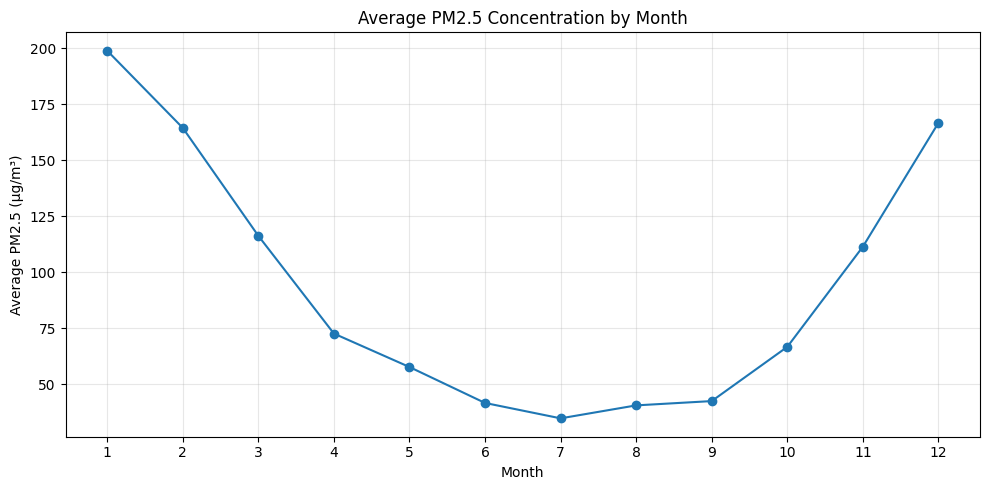

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_pm25.index,
    monthly_pm25["mean"],
    marker="o"
)

plt.title("Average PM2.5 Concentration by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Add month information to the QC daily dataset
daily_pm25_qc = daily_pm25_qc.copy()

daily_pm25_qc["month"] = pd.to_datetime(
    daily_pm25_qc.index
).month

monthly_pm25_qc = (
    daily_pm25_qc.groupby("month")["mean"]
    .agg(["mean", "median", "count"])
    .round(2)
)

display(monthly_pm25_qc)

,mean,median,count
month,,,
1,200.35,196.88,227
2,165.54,156.96,185
3,117.08,110.73,210
4,71.66,63.85,190
5,57.20,56.70,196
6,41.49,40.02,218
7,35.38,33.33,193
8,40.47,34.21,203
9,42.02,39.04,185


In [21]:
daily_pm25_qc["year"] = pd.to_datetime(
    daily_pm25_qc.index
).year

yearly_pm25 = (
    daily_pm25_qc.groupby("year")["mean"]
    .agg(["mean", "median", "count"])
    .round(2)
)

display(yearly_pm25)

,mean,median,count
year,,,
2016,144.75,139.31,47
2017,77.48,55.60,256
2018,89.22,66.06,166
2019,88.19,68.57,325
2020,85.48,59.57,314
2021,100.67,81.25,295
2022,97.05,75.00,303
2023,91.67,71.92,302
2024,98.44,71.98,354


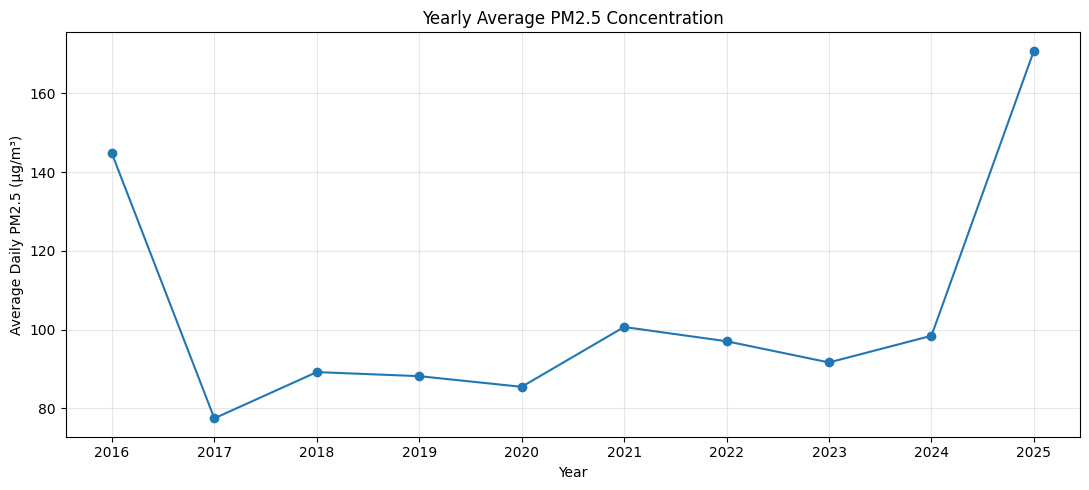

In [22]:
plt.figure(figsize=(11, 5))

plt.plot(
    yearly_pm25.index,
    yearly_pm25["mean"],
    marker="o"
)

plt.title("Yearly Average PM2.5 Concentration")
plt.xlabel("Year")
plt.ylabel("Average Daily PM2.5 (µg/m³)")
plt.xticks(yearly_pm25.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
coverage = (
    df.groupby("year")["value"]
    .agg(
        total_hours="size",
        valid_hours="count"
    )
)

coverage["coverage_percent"] = (
    coverage["valid_hours"] /
    coverage["total_hours"] * 100
).round(2)

display(coverage)

,total_hours,valid_hours,coverage_percent
year,,,
2016,1201,1182,98.42
2017,7017,6583,93.82
2018,7025,4989,71.02
2019,8283,8047,97.15
2020,8188,7918,96.70
2021,7983,7267,91.03
2022,8441,7595,89.98
2023,7493,7340,97.96
2024,8761,8336,95.15


In [24]:
for year in sorted(df["year"].unique()):
    year_data = df[df["year"] == year]
    
    print(
        year,
        "→",
        year_data["from_local"].min().date(),
        "to",
        year_data["from_local"].max().date()
    )

2016 → 2016-11-09 to 2016-12-31
2017 → 2017-01-01 to 2017-12-31
2018 → 2018-01-01 to 2018-12-31
2019 → 2019-01-01 to 2019-12-31
2020 → 2020-01-01 to 2020-12-31
2021 → 2021-01-01 to 2021-12-31
2022 → 2022-01-01 to 2022-12-31
2023 → 2023-01-01 to 2023-12-31
2024 → 2024-01-01 to 2024-12-31
2025 → 2025-01-01 to 2025-03-24


In [25]:
# Keep only January, February and March
q1_data = df[df["month"].isin([1, 2, 3])].copy()

# Calculate average PM2.5 by year
q1_yearly = (
    q1_data.groupby("year")["value"]
    .agg(["mean", "median", "count"])
    .round(2)
)

display(q1_yearly)

,mean,median,count
year,,,
2017,146.10,134.7,1924
2018,153.00,134.0,1164
2019,162.34,137.5,2020
2020,147.39,137.0,2068
2021,180.48,166.5,1950
2022,151.53,143.0,1977
2023,181.80,181.0,956
2024,161.80,152.0,2081
2025,170.82,146.0,1972


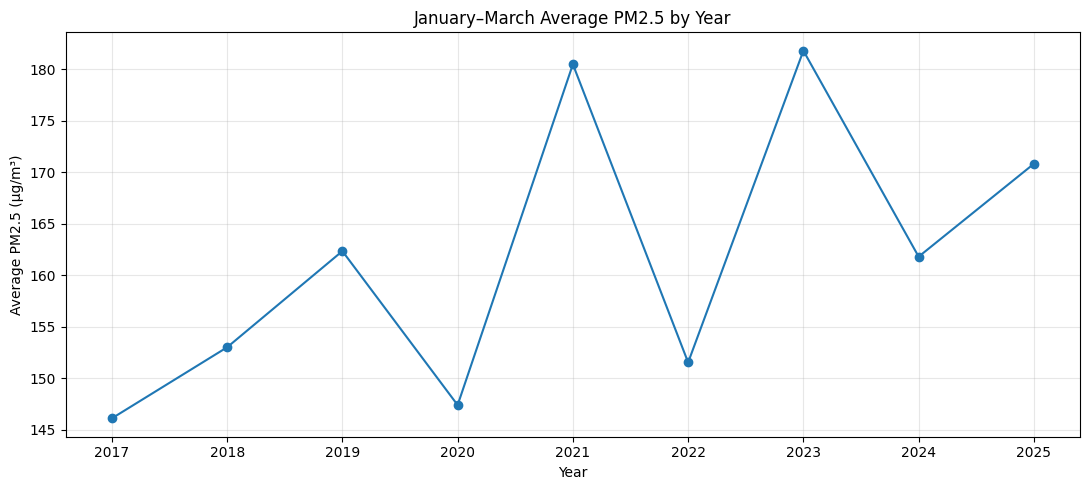

In [26]:
plt.figure(figsize=(11, 5))

plt.plot(
    q1_yearly.index,
    q1_yearly["mean"],
    marker="o"
)

plt.title("January–March Average PM2.5 by Year")
plt.xlabel("Year")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(q1_yearly.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
first_year = q1_yearly.index.min()
last_year = q1_yearly.index.max()

first_value = q1_yearly.loc[first_year, "mean"]
last_value = q1_yearly.loc[last_year, "mean"]

change_percent = ((last_value - first_value) / first_value) * 100

print(f"First comparable year: {first_year} → {first_value} µg/m³")
print(f"Latest comparable year: {last_year} → {last_value} µg/m³")
print(f"Change: {change_percent:.2f}%")

First comparable year: 2017 → 146.1 µg/m³
Latest comparable year: 2025 → 170.82 µg/m³
Change: 16.92%


In [28]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    
    print(f"{indent}{os.path.basename(root)}/")
    
    for file in files[:20]:
        print(f"{indent}  {file}")

input/
  datasets/
    mahbubaeka/
      dhaka-hourly-pm2-5-airnow-openaq-8415/
        pm25_sensor_24434.csv


In [29]:
with open("find_empty.py", "r", encoding="utf-8") as f:
    print(f.read())

FileNotFoundError: [Errno 2] No such file or directory: 'find_empty.py'

In [41]:
import os

for root, dirs, files in os.walk("/kaggle"):
    if "find_empty.py" in files:
        print(os.path.join(root, "find_empty.py"))